    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [2]:
inds_10 = pd.read_csv('csv/10_industry.csv')
inds_10['Date'] = pd.to_datetime(inds_10['Date'])
inds_10 = inds_10.set_index('Date')
inds_10.info()
inds_10

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NoDur   6539 non-null   float64
 1   Durbl   6539 non-null   float64
 2   Manuf   6539 non-null   float64
 3   Enrgy   6539 non-null   float64
 4   HiTec   6539 non-null   float64
 5   Telcm   6539 non-null   float64
 6   Shops   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Utils   6539 non-null   float64
 9   Other   6539 non-null   float64
dtypes: float64(10)
memory usage: 561.9 KB


,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
2000-01-03,-1.65,-1.36,-2.49,-3.08,2.47,-1.26,-2.30,-0.58,-2.37,-3.31
2000-01-04,-1.81,-2.60,-2.68,-1.96,-5.34,-4.40,-3.28,-4.39,0.47,-3.68
2000-01-05,-0.13,-0.04,0.57,2.26,-1.09,0.01,-0.38,2.32,3.48,-0.38
2000-01-06,0.68,0.58,2.17,4.00,-4.93,-1.92,0.24,2.68,0.57,2.34
2000-01-07,2.11,4.81,3.21,1.16,3.51,0.93,4.27,7.61,1.13,1.99
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.36,0.00,0.46,-0.33,0.17,0.64,0.51,0.58,0.38,0.42
2025-12-26,-0.07,-1.65,-0.13,-0.30,0.09,-0.18,0.13,-0.05,-0.16,-0.05
2025-12-29,0.19,-2.68,-0.38,1.02,-0.40,0.43,-0.21,-0.26,0.26,-0.57


In [3]:
torch.manual_seed(42)

N_STOCKS   = len(inds_10.columns)
LOOKBACK   = 21
HORIZON    = 21

INPUT_DIM  = LOOKBACK * N_STOCKS
HIDDEN_DIM = 64
N          = HORIZON
M          = N_STOCKS

n1    = 0.50
C     = 1.0
d     = 1.0
x_min = 0.0
x_max = 0.30
lam   = 1.0

EPOCHS     = 100
BATCH_SIZE = 16
LR         = 1e-4

In [4]:
inds_10 = inds_10.sort_index()   # ← 이 한 줄 추가
inds_10 = inds_10[~inds_10.index.duplicated(keep='first')]  # ← 없음
inds_10 = inds_10 / 100.0

stock_names = inds_10.columns.tolist()

# =============================================================================
# 2. IS / OOS 분리 (날짜 기준)
# =============================================================================
IS_START = "2000-01-01"
IS_END   = "2017-12-31"
BT_START = "2018-01-01"
BT_END   = "2025-12-31"

is_df = inds_10[IS_START : IS_END]
bt_df = inds_10[BT_START : BT_END]

is_np  = is_df.values
bt_np  = bt_df.values

N_IS   = len(is_df)
N_BT   = len(bt_df)
N_DAYS = len(inds_10)

print(f"전체 : {inds_10.index[0].date()} → {inds_10.index[-1].date()}  ({N_DAYS} days)")
print(f"IS   : {is_df.index[0].date()} → {is_df.index[-1].date()}  ({N_IS} days)")
print(f"BT   : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목 : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
is_mean = is_np.mean(axis=0)   # shape (10,)
is_std  = is_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (21, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # IS 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

is_samples = make_windows(is_np, LOOKBACK, HORIZON,
                          start=LOOKBACK, end=N_IS)

full_np      = np.vstack([is_np, bt_np])
BT_START_IDX = N_IS

rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                             start=BT_START_IDX, end=BT_START_IDX + N_BT)
rebal_samples = rebal_samples[::HORIZON]

is_years = (is_df.index[-1] - is_df.index[0]).days / 365.25
bt_years = (bt_df.index[-1] - bt_df.index[0]).days / 365.25

print(f"\nIS 학습 샘플 수  : {len(is_samples)}")
print(f"BT 리밸런싱 횟수 : {len(rebal_samples)}")


전체 : 2000-01-03 → 2025-12-31  (6539 days)
IS   : 2000-01-03 → 2017-12-29  (4528 days)
BT   : 2018-01-02 → 2025-12-31  (2011 days)
종목 : ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']

IS 학습 샘플 수  : 4487
BT 리밸런싱 횟수 : 95



── IS Training ──
  Epoch   1/100  loss = 0.027441
  Epoch   5/100  loss = 0.023484
  Epoch  10/100  loss = 0.023217


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/diffcp/cone_program.py:522: UserWarning: Solved/Inaccurate.
  warnings.warn("Solved/Inaccurate.")


  Epoch  15/100  loss = 0.022819
  Epoch  20/100  loss = 0.022407
  Epoch  25/100  loss = 0.022310
  Epoch  30/100  loss = 0.021906
  Epoch  35/100  loss = 0.021445
  Epoch  40/100  loss = 0.020937
  Epoch  45/100  loss = 0.020554
  Epoch  50/100  loss = 0.019875
  Epoch  55/100  loss = 0.019570
  Epoch  60/100  loss = 0.019007
  Epoch  65/100  loss = 0.018178
  Epoch  70/100  loss = 0.017820
  Epoch  75/100  loss = 0.017333
  Epoch  80/100  loss = 0.016605
  Epoch  85/100  loss = 0.016241
  Epoch  90/100  loss = 0.015657
  Epoch  95/100  loss = 0.015422
  Epoch 100/100  loss = 0.014747

── Backtest : DFL-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 646.12it/s]

    1    0.0308   1.2615%  {'Utils': 0.3, 'Shops': 0.3, 'NoDur': 0.3}
    2   -0.0475   6.7251%  {'Utils': 0.3, 'Shops': 0.3, 'Hlth': 0.21}
    3   -0.0256   6.3012%  {'Hlth': 0.3, 'Shops': 0.3, 'NoDur': 0.3}
    4   -0.0207   5.0517%  {'Hlth': 0.3, 'Manuf': 0.3, 'NoDur': 0.3}
    5    0.0200   1.0097%  {'Utils': 0.3, 'Hlth': 0.3, 'NoDur': 0.3}
    6    0.0297   0.4371%  {'Utils': 0.3, 'Shops': 0.3, 'NoDur': 0.3}
    7    0.0274   0.8131%  {'Utils': 0.3, 'Hlth': 0.3, 'NoDur': 0.3}
    8    0.0212   1.0512%  {'Utils': 0.3, 'Hlth': 0.3, 'NoDur': 0.3}
    9    0.0033   1.9456%  {'Utils': 0.3, 'Shops': 0.3, 'NoDur': 0.3}
   10   -0.0695   8.3935%  {'Utils': 0.3, 'Shops': 0.3, 'Manuf': 0.3}
   11    0.0083   7.1158%  {'Shops': 0.3, 'Enrgy': 0.3, 'NoDur': 0.3}
   12   -0.0788  13.6887%  {'Utils': 0.3, 'Hlth': 0.3, 'NoDur': 0.3}
   13    0.0767   1.3396%  {'Manuf': 0.3, 'NoDur': 0.3, 'Hlth': 0.276}
   14    0.0343   0.7113%  {'Utils': 0.3, 'Manuf': 0.3, 'NoDur': 0.3}
   15    0.0171   0.8291%

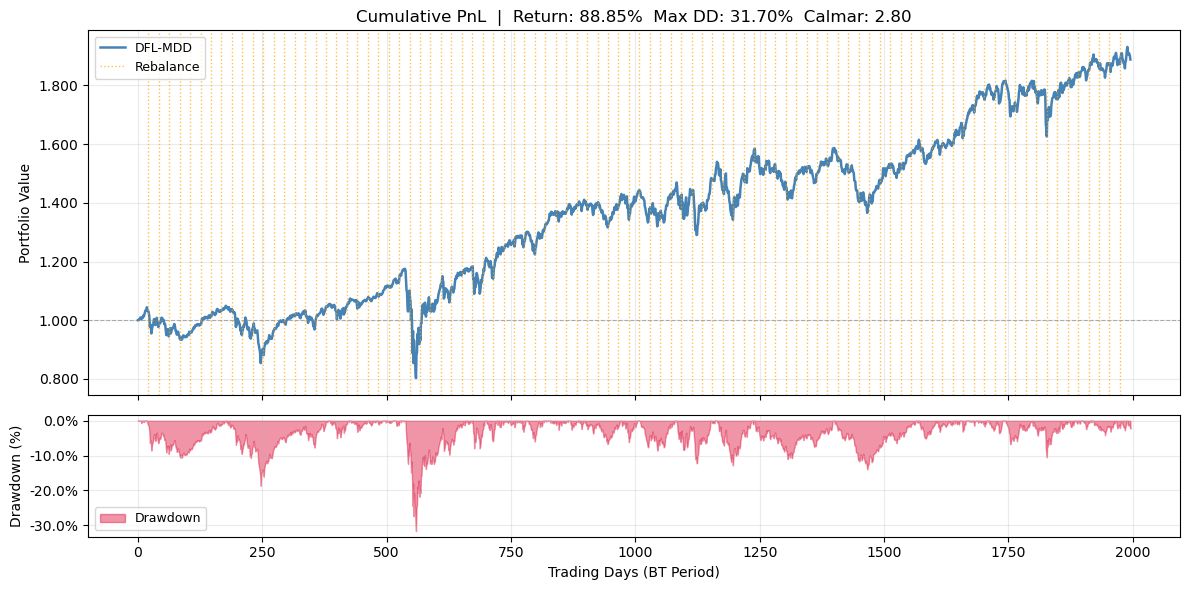


── PnL Summary (DFL-MDD) ──
  Final Value  : 1.8885
  Total Return : 88.8498%
  Max Drawdown : 31.6960%
  Calmar Ratio : 2.8032


In [8]:
import importlib
import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel,
    build_optimization_layer,
    solve_portfolio,
    compute_cumulative_path,
    compute_realized_path,
    compute_return,
    compute_max_drawdown,
    dfl_loss,
    forward_pass,
    backtest_dfl_mdd,
    plot_pnl,
)

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False 

pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
opt_layer  = build_optimization_layer(N, M, 0.1)
optimizer  = optim.Adam(pred_model.parameters(), lr=LR)


zs_is = torch.tensor(np.array([s[0] for s in is_samples]), dtype=torch.float32)
rs_is = torch.tensor(np.array([s[1] for s in is_samples]), dtype=torch.float32)

print("\n── IS Training ──")
pred_model.train()

for epoch in range(EPOCHS):
    perm   = torch.randperm(len(is_samples))
    ep_loss = []

    for i in range(0, len(is_samples), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        z_b = zs_is[idx]
        r_b = rs_is[idx]

        optimizer.zero_grad()
        result = forward_pass(z_b, r_b, pred_model, opt_layer,
                              n1, C, d, x_min, x_max, lam)
        result["loss"].backward()
        optimizer.step()
        ep_loss.append(result["loss"].item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss = {np.mean(ep_loss):.6f}")


bt_dfl_mdd = backtest_dfl_mdd(
    pred_model    = pred_model,
    opt_layer     = opt_layer,
    rebal_samples = rebal_samples,
    N             = HORIZON,
    d             = d,
    C             = C,
    n1            = n1,
    x_min         = x_min,
    x_max         = x_max,
    stock_names   = stock_names,
)


plot_pnl(bt_dfl_mdd, horizon=HORIZON, label = "DFL-MDD")


── PTO-MDD Training (MSE) ──
  Epoch   1/100  mse = 0.005849
  Epoch   5/100  mse = 0.000388
  Epoch  10/100  mse = 0.000224
  Epoch  15/100  mse = 0.000199
  Epoch  20/100  mse = 0.000193
  Epoch  25/100  mse = 0.000191
  Epoch  30/100  mse = 0.000190
  Epoch  35/100  mse = 0.000189
  Epoch  40/100  mse = 0.000188
  Epoch  45/100  mse = 0.000186
  Epoch  50/100  mse = 0.000184
  Epoch  55/100  mse = 0.000182
  Epoch  60/100  mse = 0.000180
  Epoch  65/100  mse = 0.000178
  Epoch  70/100  mse = 0.000177
  Epoch  75/100  mse = 0.000175
  Epoch  80/100  mse = 0.000174
  Epoch  85/100  mse = 0.000172
  Epoch  90/100  mse = 0.000171
  Epoch  95/100  mse = 0.000170
  Epoch 100/100  mse = 0.000169

── Backtest : PTO-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------
    1    0.0412   1.6722%  {'Manuf': 0.128, 'Telcm': 0.113, 'Shops': 0.107}
    2   -0.0538   8.0965%  {'Manuf': 0.116, 'NoDur': 0.113, 'Shops': 0.108}
    3   -0.015

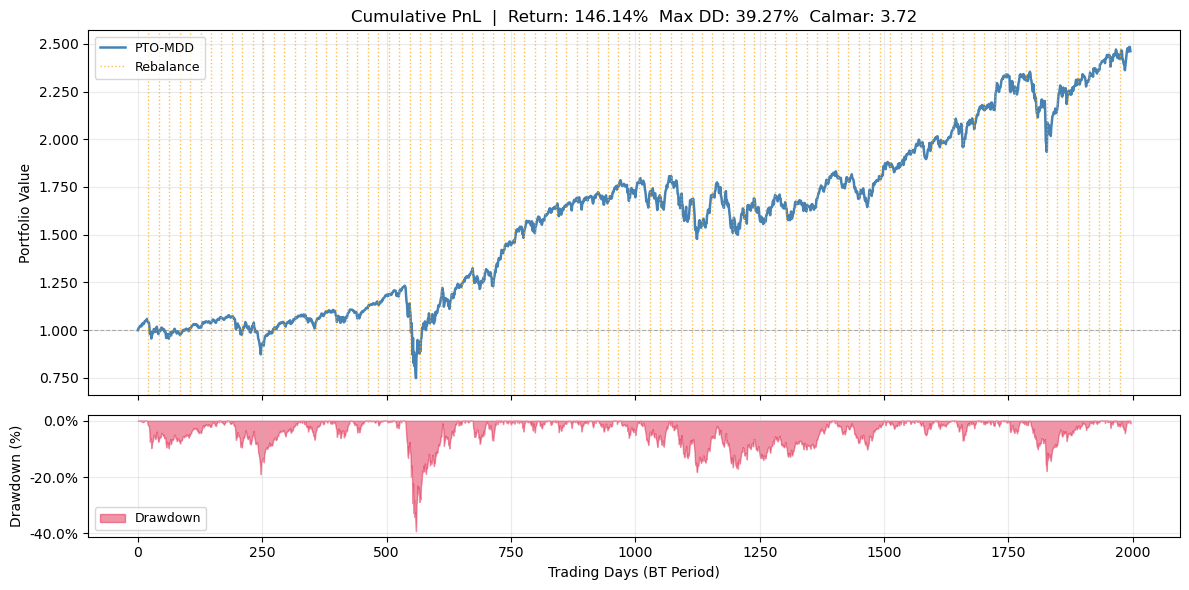


── PnL Summary (PTO-MDD) ──
  Final Value  : 2.4614
  Total Return : 146.1437%
  Max Drawdown : 39.2680%
  Calmar Ratio : 3.7217


In [9]:
import importlib
import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd  import train_pto_mdd,  backtest_pto_mdd

model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

train_pto_mdd(model_pto_mdd, is_samples, EPOCHS, BATCH_SIZE, LR)


bt_pto_mdd = backtest_pto_mdd(
    pred_model   = model_pto_mdd,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    n1           = n1,
    x_min        = x_min,
    x_max        = x_max,
    gamma        = 0.1,
    stock_names  = stock_names,
)


plot_pnl(bt_pto_mdd, horizon=HORIZON, label = 'PTO-MDD')



── PTO-MVO Training (MSE) ──
  Epoch   1/100  mse = 0.005422
  Epoch   5/100  mse = 0.000421
  Epoch  10/100  mse = 0.000231
  Epoch  15/100  mse = 0.000202
  Epoch  20/100  mse = 0.000194
  Epoch  25/100  mse = 0.000191
  Epoch  30/100  mse = 0.000190
  Epoch  35/100  mse = 0.000189
  Epoch  40/100  mse = 0.000187
  Epoch  45/100  mse = 0.000185
  Epoch  50/100  mse = 0.000184
  Epoch  55/100  mse = 0.000182
  Epoch  60/100  mse = 0.000180
  Epoch  65/100  mse = 0.000178
  Epoch  70/100  mse = 0.000176
  Epoch  75/100  mse = 0.000175
  Epoch  80/100  mse = 0.000173
  Epoch  85/100  mse = 0.000172
  Epoch  90/100  mse = 0.000171
  Epoch  95/100  mse = 0.000170
  Epoch 100/100  mse = 0.000168

── Backtest : PTO-MVO ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------
    1    0.0367   2.0634%  {'Enrgy': 0.3, 'Durbl': 0.3, 'Manuf': 0.3}
    2   -0.0640   8.9903%  {'Enrgy': 0.3, 'Utils': 0.3, 'Manuf': 0.3}
    3    0.0057   3.2254% 

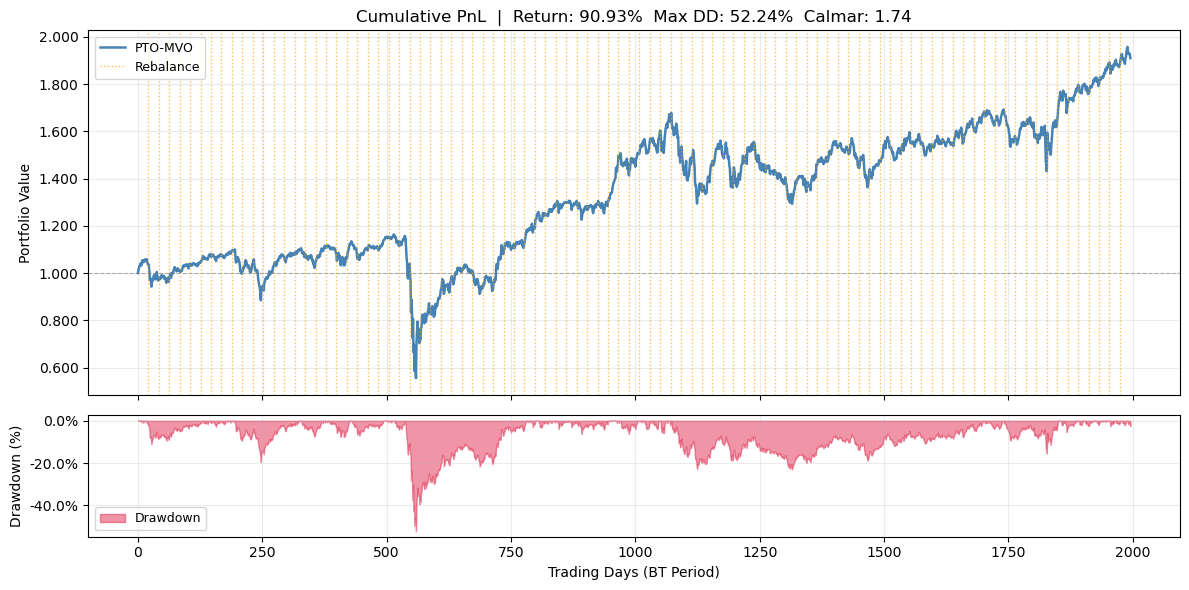


── PnL Summary (PTO-MVO) ──
  Final Value  : 1.9093
  Total Return : 90.9265%
  Max Drawdown : 52.2448%
  Calmar Ratio : 1.7404


In [10]:
import importlib
import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo  import train_pto_mvo,  backtest_pto_mvo 

model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

train_pto_mvo(model_pto_mvo, is_samples, EPOCHS, BATCH_SIZE, LR)

bt_pto_mvo = backtest_pto_mvo(
    pred_model   = model_pto_mvo,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    lam_mvo      = 1.0,
    x_min        = x_min,
    x_max        = x_max,
    stock_names  = stock_names,
)

plot_pnl(bt_pto_mvo, horizon=HORIZON, label = 'PTO-MVO')